In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pixel shuffling ("pmix"), shuffle rows only

In [6]:
test_accs = []
for fpath in ["results/results_pmix"+str(i) for i in range(4)] + ["results/results_pmix_0"]:
    with open(fpath) as fp:
        l = fp.readlines()
        test_accs.append(float(l[-1][-8:-3]))
test_accs = np.array(test_accs)
test_accs

array([67.28, 66.22, 66.75, 62.97, 66.36])

## Pixel shuffling ("pmix"), shuffle pixels

In [3]:
test_accs2 = []
for fpath in ["results/results_pmix"+str(i) for i in range(4)]:
    with open(fpath) as fp:
        l = fp.readlines()
        test_accs2.append(float(l[-1][-8:-3]))
test_accs2 = np.array(test_accs2)

## Pixel shuffling ("pmix") + mix-up 

In [4]:
test_accs3 = []
for fpath in ["results/results_pmixup_"+str(i) for i in range(4)] + ["results/results_pmixup"]:
    with open(fpath) as fp:
        l = fp.readlines()
        test_accs3.append(float(l[-1][-8:-3]))
test_accs3 = np.array(test_accs3)

## Results

In [5]:
df = pd.DataFrame(index=["pmix (rows)", "pmix", "pmixup"])
tests = [test_accs, test_accs2, test_accs3]
df["mean"] = [ta.mean() for ta in tests]
df["standard deviation"] = [ta.std() for ta in tests]
df["min"] = [ta.min() for ta in tests]
df["max"] = [ta.max() for ta in tests]
df["pop size"] = [ta.shape[0] for ta in tests]
df["sqrt pop size"] = [np.sqrt(ta.shape[0]) for ta in tests]
df["lower 95% CI bound"] = df["mean"] - df["standard deviation"] * 1.96 / df["sqrt pop size"]
df["upper 95% CI bound"] = df["mean"] + df["standard deviation"] * 1.96 / df["sqrt pop size"]

df

,mean,standard deviation,min,max,pop size,sqrt pop size,lower 95% CI bound,upper 95% CI bound
pmix (rows),65.916,1.518191,62.97,67.28,5,2.236068,64.585247,67.246753
pmix,65.805,1.679144,62.97,67.28,4,2.000000,64.159439,67.450561
pmixup,19.116,0.677926,18.35,20.21,5,2.236068,18.521771,19.710229


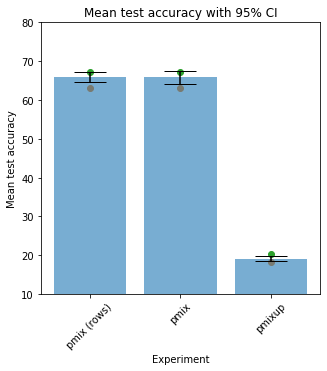

In [7]:
fig, ax = plt.subplots(figsize=(5,5))
yerr = np.array([(df["lower 95% CI bound"] - df["mean"]).abs(), list(df["upper 95% CI bound"] - df["mean"])])
ax.bar(df.index, df["mean"],
       yerr=yerr, align="center",
       alpha=0.6, capsize=16)
ax.set_ylim(10, 80)
ax.scatter(df.index, df["min"])
ax.scatter(df.index, df["max"])
plt.xticks(rotation=45)
plt.title("Mean test accuracy with 95% CI")
plt.xlabel("Experiment")
plt.ylabel("Mean test accuracy")
plt.show()